# 🚨 Criminal Face Recognition — Transfer Learning (MobileNetV2)
### Optimized for Low-Spec CPU (8GB RAM) — Fast Training Version

**Key improvements over custom CNN:**
- ⚡ ~10x faster training using MobileNetV2 pretrained weights
- 🧠 Starts with ImageNet knowledge (edges, faces, textures)
- 📦 Image size reduced to 96×96 (was 150×150) → 2.5x fewer pixels
- 🎯 Phase 1: Train only head (fast) → Phase 2: Fine-tune last 2 layers only
- 💾 Saves best model automatically via EarlyStopping + ModelCheckpoint

---

### Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import pathlib as pl
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import PIL
from PIL import Image
import cv2

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))
print("✅ Libraries loaded")

TensorFlow version: 2.20.0
GPU Available: []
✅ Libraries loaded


### Step 2: Configuration — Set All Paths & Hyperparameters Here

In [4]:
# ============================================================
# ← UPDATE THESE PATHS
# ============================================================
DATA_DIR        = r"C:/Users/Lenovo/project/Criminal Face Recognition/criminal_dataset"
CRIMINAL_CSV    = r"C:/Users/Lenovo/project/Criminal Face Recognition/criminals_info.csv"
MODEL_SAVE_PATH = r"C:/Users/Lenovo/project/Criminal Face Recognition/criminal_recognition_model.h5"

# ============================================================
# Image & Training Config
# ============================================================
IMG_SIZE   = 96          # MobileNetV2 works great at 96x96 — much faster than 150x150
BATCH_SIZE = 32          # 32 is safest for 8GB RAM — use 16 if RAM issues
NUM_CLASSES = 14

# Phase 1 — Train head only (fast)
PHASE1_EPOCHS = 50      # Should finish in 20-30 mins total on CPU
PHASE1_LR     = 0.001

# Phase 2 — Fine-tune last 2 layers only (careful/slow)
PHASE2_EPOCHS = 50       # Additional epochs on top of phase 1
PHASE2_LR     = 0.0001   # Must be much lower than phase 1

# Confidence threshold for predictions
CONFIDENCE_THRESHOLD = 0.70

# Validation split
VAL_SPLIT = 0.2

print(f"Config loaded:")
print(f"  Image size : {IMG_SIZE}x{IMG_SIZE}")
print(f"  Batch size : {BATCH_SIZE}")
print(f"  Phase 1    : {PHASE1_EPOCHS} epochs @ lr={PHASE1_LR}")
print(f"  Phase 2    : {PHASE2_EPOCHS} epochs @ lr={PHASE2_LR} (fine-tune)")

Config loaded:
  Image size : 96x96
  Batch size : 32
  Phase 1    : 50 epochs @ lr=0.001
  Phase 2    : 50 epochs @ lr=0.0001 (fine-tune)


### Step 3: Load & Explore Dataset

In [5]:
data_dir = pl.Path(DATA_DIR)

image_count = len(list(data_dir.glob('*/*.jpg')))
print(f"Total images: {image_count}\n")

print(f"{'Criminal Name':<50} | {'Image Count':>12}")
print("=" * 65)
for folder in sorted(data_dir.glob("*")):
    if folder.is_dir():
        count = len(list(folder.glob('*.jpg')))
        print(f"{folder.name:<50} | {count:>12}")

Total images: 7540

Criminal Name                                      |  Image Count
Aniket_Kakad                                       |          250
Atharva_Ayachit                                    |          693
Chandrakant_Kshirsagar                             |          603
Dhananjay_Patil                                    |          585
Ishika_Mehre                                       |          603
Japneet_Singh                                      |          558
Jay_Kumar                                          |          504
Jivan Ayachit                                      |          396
Jyoti Ayachit                                      |          468
Kajal_Yerone                                       |          639
Sakshi_Lahekar                                     |          468
Sayali_Chidrawar                                   |          576
Shreyas_Jadhav                                     |          603
Tushar_Patil                                       |    

### Step 4: Preview Sample Images

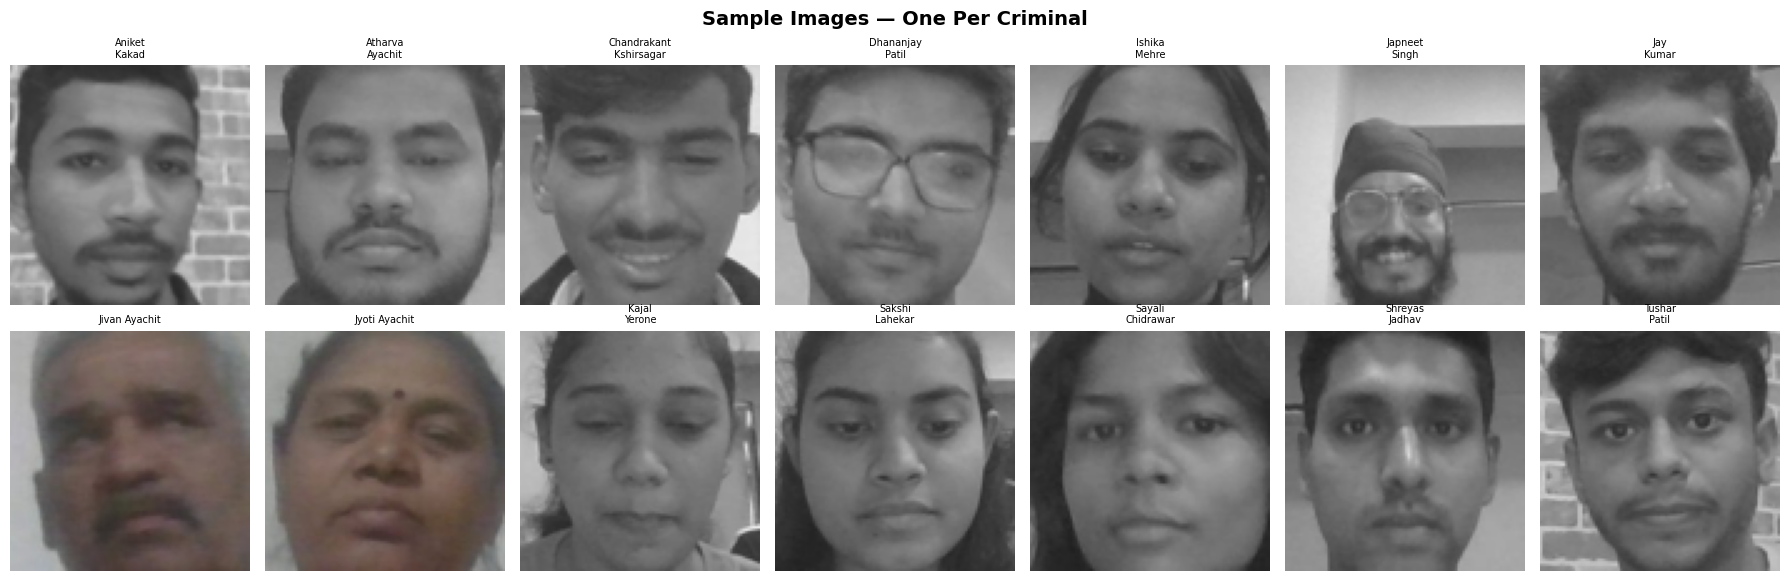

In [6]:
folders = sorted([f for f in data_dir.glob("*") if f.is_dir()])

fig, axes = plt.subplots(2, 7, figsize=(18, 6))
axes = axes.flatten()

for i, folder in enumerate(folders[:14]):
    imgs = list(folder.glob("*.jpg"))
    if imgs:
        img = Image.open(imgs[0]).resize((96, 96))
        axes[i].imshow(img)
        axes[i].set_title(folder.name.replace('_', '\n'), fontsize=7)
        axes[i].axis('off')

plt.suptitle("Sample Images — One Per Criminal", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Step 5: Data Generators with MobileNetV2 Preprocessing

> ⚠️ **Critical:** MobileNetV2 requires `preprocess_input` (scales to [-1, 1])  
> Do NOT use `/255.0` scaling when using this model — `preprocess_input` handles it.

In [7]:
# Training data generator — WITH augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # MobileNetV2 required preprocessing
    validation_split=VAL_SPLIT,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# Validation generator — NO augmentation, only preprocessing
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=VAL_SPLIT
)

# Training generator
train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

# Validation generator
val_generator = val_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

# Get class names (alphabetical order — matches TF folder sorting)
class_names = list(train_generator.class_indices.keys())
print(f"\nClasses ({len(class_names)}): {class_names}")
print(f"\nTraining samples  : {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")
print(f"Steps per epoch   : {train_generator.samples // BATCH_SIZE}")

Found 6039 images belonging to 14 classes.
Found 1501 images belonging to 14 classes.

Classes (14): ['Aniket_Kakad', 'Atharva_Ayachit', 'Chandrakant_Kshirsagar', 'Dhananjay_Patil', 'Ishika_Mehre', 'Japneet_Singh', 'Jay_Kumar', 'Jivan Ayachit', 'Jyoti Ayachit', 'Kajal_Yerone', 'Sakshi_Lahekar', 'Sayali_Chidrawar', 'Shreyas_Jadhav', 'Tushar_Patil']

Training samples  : 6039
Validation samples: 1501
Steps per epoch   : 188


### Step 6: Save Class Names to File

In [8]:
# Save class names — needed by the Streamlit app
class_names_path = Path(MODEL_SAVE_PATH).parent / "class_names.txt"
with open(class_names_path, 'w') as f:
    f.write('\n'.join(class_names))
    
print(f"Class names saved to: {class_names_path}")
print("\nOrder:")
for i, name in enumerate(class_names):
    print(f"  {i:2d}: {name}")

Class names saved to: C:\Users\Lenovo\project\Criminal Face Recognition\class_names.txt

Order:
   0: Aniket_Kakad
   1: Atharva_Ayachit
   2: Chandrakant_Kshirsagar
   3: Dhananjay_Patil
   4: Ishika_Mehre
   5: Japneet_Singh
   6: Jay_Kumar
   7: Jivan Ayachit
   8: Jyoti Ayachit
   9: Kajal_Yerone
  10: Sakshi_Lahekar
  11: Sayali_Chidrawar
  12: Shreyas_Jadhav
  13: Tushar_Patil


### Step 7: Build Model — MobileNetV2 + Custom Head

**Architecture:**
```
Input (96×96×3)
    ↓
MobileNetV2 base [FROZEN in Phase 1]
    ↓
GlobalAveragePooling2D
    ↓
BatchNormalization
    ↓
Dropout(0.4)
    ↓
Dense(128, relu)
    ↓
Dropout(0.3)
    ↓
Dense(14, softmax)  ← Output
```

In [9]:
# Load MobileNetV2 — pretrained on ImageNet, without top classifier
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,       # Remove ImageNet classifier
    weights='imagenet'       # Use pretrained weights
)

# PHASE 1: Freeze entire base — only train our custom head
base_model.trainable = False

# Build custom head on top of base
x = base_model.output
x = GlobalAveragePooling2D()(x)           # Replaces Flatten — much fewer params
x = BatchNormalization()(x)               # Stabilizes training
x = Dropout(0.4)(x)                       # Regularization
x = Dense(128, activation='relu')(x)      # Feature compression
x = Dropout(0.3)(x)                       # More regularization
output = Dense(NUM_CLASSES, activation='softmax')(x)  # Final classification

model = Model(inputs=base_model.input, outputs=output)

# Count trainable vs frozen params
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
total_params = sum([tf.size(w).numpy() for w in model.weights])
frozen_params = total_params - trainable_params

print(f"Total parameters    : {total_params:,}")
print(f"Trainable (Phase 1) : {trainable_params:,}")
print(f"Frozen              : {frozen_params:,}")
print(f"\n✅ Base model FROZEN — training head only in Phase 1")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Total parameters    : 2,428,878
Trainable (Phase 1) : 168,334
Frozen              : 2,260,544

✅ Base model FROZEN — training head only in Phase 1


### Step 8: Phase 1 — Train Custom Head (Fast)

In [10]:
# Compile for Phase 1
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=PHASE1_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
callbacks_phase1 = [
    # Save best model automatically
    ModelCheckpoint(
        filepath=MODEL_SAVE_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    # Stop early if no improvement for 7 epochs
    EarlyStopping(
        monitor='val_accuracy',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce LR if stuck
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

print("🚀 Starting Phase 1 Training — Head Only (Fast)...")
print(f"   Epochs: up to {PHASE1_EPOCHS} (EarlyStopping may stop earlier)")
print(f"   Steps/epoch: ~{train_generator.samples // BATCH_SIZE}")
print("")

history1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=PHASE1_EPOCHS,
    callbacks=callbacks_phase1,
    verbose=1
)

print("\n✅ Phase 1 Complete!")

🚀 Starting Phase 1 Training — Head Only (Fast)...
   Epochs: up to 50 (EarlyStopping may stop earlier)
   Steps/epoch: ~188

Epoch 1/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 550ms/step - accuracy: 0.6069 - loss: 1.4470
Epoch 1: val_accuracy improved from None to 0.95736, saving model to C:/Users/Lenovo/project/Criminal Face Recognition/criminal_recognition_model.h5



Epoch 1: finished saving model to C:/Users/Lenovo/project/Criminal Face Recognition/criminal_recognition_model.h5
189/189 ━━━━━━━━━━━━━━━━━━━━ 168s 745ms/step - accuracy: 0.7740 - loss: 0.7860 - val_accuracy: 0.9574 - val_loss: 0.1616 - learning_rate: 0.0010
Epoch 2/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 580ms/step - accuracy: 0.9001 - loss: 0.3098
Epoch 2: val_accuracy improved from 0.95736 to 0.95936, saving model to C:/Users/Lenovo/project/Criminal Face Recognition/criminal_recognition_model.h5



Epoch 2: finished saving model to C:/Users/Lenovo/project/Criminal Face Recognition/criminal_recognition_model.h5
189/189 ━━━━━━━━━━━━━━━━━━━━ 133s 694ms/step - accuracy: 0.9033 - loss: 0.2917 - val_accuracy: 0.9594 - val_loss: 0.1406 - learning_rate: 0.0010
Epoch 3/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 653ms/step - accuracy: 0.9308 - loss: 0.2148
Epoch 3: val_accuracy improved from 0.95936 to 0.96869, saving model to C:/Users/Lenovo/project/Criminal Face Recognition/criminal_recognition_model.h5



Epoch 3: finished saving model to C:/Users/Lenovo/project/Criminal Face Recognition/criminal_recognition_model.h5
189/189 ━━━━━━━━━━━━━━━━━━━━ 156s 822ms/step - accuracy: 0.9333 - loss: 0.2008 - val_accuracy: 0.9687 - val_loss: 0.1328 - learning_rate: 0.0010
Epoch 4/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 715ms/step - accuracy: 0.9439 - loss: 0.1673
Epoch 4: val_accuracy did not improve from 0.96869
189/189 ━━━━━━━━━━━━━━━━━━━━ 150s 788ms/step - accuracy: 0.9419 - loss: 0.1741 - val_accuracy: 0.9660 - val_loss: 0.1459 - learning_rate: 0.0010
Epoch 5/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 698ms/step - accuracy: 0.9475 - loss: 0.1634
Epoch 5: val_accuracy improved from 0.96869 to 0.98135, saving model to C:/Users/Lenovo/project/Criminal Face Recognition/criminal_recognition_model.h5



Epoch 5: finished saving model to C:/Users/Lenovo/project/Criminal Face Recognition/criminal_recognition_model.h5
189/189 ━━━━━━━━━━━━━━━━━━━━ 156s 826ms/step - accuracy: 0.9480 - loss: 0.1585 - val_accuracy: 0.9813 - val_loss: 0.0989 - learning_rate: 0.0010
Epoch 6/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 805ms/step - accuracy: 0.9490 - loss: 0.1743
Epoch 6: val_accuracy did not improve from 0.98135
189/189 ━━━━━━━━━━━━━━━━━━━━ 171s 895ms/step - accuracy: 0.9523 - loss: 0.1558 - val_accuracy: 0.9720 - val_loss: 0.1209 - learning_rate: 0.0010
Epoch 7/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 687ms/step - accuracy: 0.9535 - loss: 0.1462
Epoch 7: val_accuracy did not improve from 0.98135
189/189 ━━━━━━━━━━━━━━━━━━━━ 155s 822ms/step - accuracy: 0.9533 - loss: 0.1429 - val_accuracy: 0.9793 - val_loss: 0.1099 - learning_rate: 0.0010
Epoch 8/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 768ms/step - accuracy: 0.9576 - loss: 0.1344
Epoch 8: val_accuracy did not improve from 0.98135

Epoch 8: ReduceLROnPlateau reduc

AbortedError: Graph execution error:

Detected at node StatefulPartitionedCall/functional_1/block_16_project_1/convolution defined at (most recent call last):
<stack traces unavailable>
Operation received an exception:Status: 1, message: could not create a memory object, in file tensorflow/core/kernels/mkl/mkl_conv_ops.cc:1112
	 [[{{node StatefulPartitionedCall/functional_1/block_16_project_1/convolution}}]] [Op:__inference_multi_step_on_iterator_9761]

### Step 9: Plot Phase 1 Training History

In [ ]:
def plot_history(history, title="Training History"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train Acc',  color='royalblue', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val Acc',    color='tomato',    linewidth=2)
    axes[0].set_title(f'{title} — Accuracy', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Loss
    axes[1].plot(history.history['loss'],     label='Train Loss', color='royalblue', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val Loss',   color='tomato',    linewidth=2)
    axes[1].set_title(f'{title} — Loss', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print best metrics
    best_val_acc = max(history.history['val_accuracy'])
    best_epoch   = history.history['val_accuracy'].index(best_val_acc) + 1
    print(f"Best Val Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}")

plot_history(history1, "Phase 1 (Head Only)")

### Step 10: Phase 2 — Fine-Tune Last 2 Layers Only

> ⚠️ Only unfreeze the **last 2 layers** of MobileNetV2.  
> This lets the model adapt slightly to your specific faces  
> without destroying the pretrained knowledge.

In [ ]:
# Unfreeze entire base first, then re-freeze all except last 2 layers
base_model.trainable = True

# Freeze everything except the last 2 layers of base_model
FINE_TUNE_FROM = len(base_model.layers) - 2

for layer in base_model.layers[:FINE_TUNE_FROM]:
    layer.trainable = False

# Verify
trainable_now = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"Total base layers       : {len(base_model.layers)}")
print(f"Fine-tuning from layer  : {FINE_TUNE_FROM} (last 2 only)")
print(f"Trainable params now    : {trainable_now:,}")

# Show which layers are now trainable
print("\nUnfrozen layers:")
for layer in base_model.layers[FINE_TUNE_FROM:]:
    print(f"  ✅ {layer.name}")

# Recompile with LOWER learning rate — very important
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=PHASE2_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase2 = [
    ModelCheckpoint(
        filepath=MODEL_SAVE_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

print("\n🔧 Starting Phase 2 — Fine-tuning last 2 layers...")

history2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=PHASE2_EPOCHS,
    callbacks=callbacks_phase2,
    verbose=1
)

print("\n✅ Phase 2 Complete!")

### Step 11: Plot Phase 2 History

In [ ]:
plot_history(history2, "Phase 2 (Fine-Tune Last 2 Layers)")

### Step 12: Combined Training History

In [ ]:
# Combine both histories for full picture
combined_acc     = history1.history['accuracy']     + history2.history['accuracy']
combined_val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
combined_loss    = history1.history['loss']         + history2.history['loss']
combined_val_loss= history1.history['val_loss']     + history2.history['val_loss']

p1_end = len(history1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, train_data, val_data, metric in zip(
    axes,
    [combined_acc, combined_loss],
    [combined_val_acc, combined_val_loss],
    ['Accuracy', 'Loss']
):
    ax.plot(train_data, label=f'Train {metric}', color='royalblue', linewidth=2)
    ax.plot(val_data,   label=f'Val {metric}',   color='tomato',    linewidth=2)
    ax.axvline(x=p1_end, color='green', linestyle='--', linewidth=1.5, label='Fine-tune starts')
    ax.set_title(f'Full Training — {metric}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(Path(MODEL_SAVE_PATH).parent / 'training_history.png'), dpi=120, bbox_inches='tight')
plt.show()
print("📊 Training graph saved!")

### Step 13: Evaluate Model — Confusion Matrix & Classification Report

In [ ]:
# Reset validation generator
val_generator.reset()

# Predict all validation samples
print("Running predictions on validation set...")
y_pred_prob = model.predict(val_generator, verbose=1)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = val_generator.classes

# Classification report
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred, target_names=class_names))

# Overall accuracy
overall_acc = np.mean(y_pred == y_true)
print(f"Overall Validation Accuracy: {overall_acc*100:.2f}%")

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[n.replace('_', '\n') for n in class_names],
    yticklabels=[n.replace('_', '\n') for n in class_names]
)
plt.title('Confusion Matrix — Validation Set', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.savefig(str(Path(MODEL_SAVE_PATH).parent / 'confusion_matrix.png'), dpi=120, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved!")

### Step 14: Save Model & Class Names

In [ ]:
# Model is already saved by ModelCheckpoint (best val_accuracy version)
# But we also do a final save here just in case
model.save(MODEL_SAVE_PATH)
print(f"✅ Model saved: {MODEL_SAVE_PATH}")

# Also save a .keras format (more reliable for TF2.x)
keras_path = MODEL_SAVE_PATH.replace('.h5', '.keras')
model.save(keras_path)
print(f"✅ Keras format saved: {keras_path}")

# Verify class names file exists
print(f"✅ Class names file: {class_names_path}")
print(f"\nFiles ready for Streamlit app:")
print(f"  Model  : {MODEL_SAVE_PATH}")
print(f"  Classes: {class_names_path}")
print(f"  CSV    : {CRIMINAL_CSV}")

### Step 15: Load Criminal Info CSV

In [ ]:
info_df = pd.read_csv(CRIMINAL_CSV)
print(f"Criminal database loaded: {len(info_df)} records")
display(info_df.head(5))

### Step 16: Prediction Function — Identify Criminal from Image

In [ ]:
def identify_criminal(image_path, model=model, class_names=class_names, info_df=info_df):
    """
    1. Loads image
    2. Detects face using Haar Cascade
    3. Preprocesses face for MobileNetV2 (preprocess_input, not /255)
    4. Runs prediction
    5. Looks up criminal info from CSV
    6. Displays result with bounding box + profile
    """
    # ── Load image ──────────────────────────────────────────────────
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print(f"❌ Could not load image: {image_path}")
        return
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # ── Face detection using OpenCV Haar Cascade ────────────────────
    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
    )
    gray  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(
        gray, scaleFactor=1.1, minNeighbors=5, minSize=(60, 60)
    )

    if len(faces) == 0:
        print("❌ No face detected in the image.")
        plt.imshow(img_rgb)
        plt.axis('off')
        plt.title("No face detected", color='red')
        plt.show()
        return

    # Use the largest face found
    x, y, w, h = sorted(faces, key=lambda f: f[2] * f[3], reverse=True)[0]
    face_crop   = img_rgb[y:y+h, x:x+w]

    # ── Preprocess face for MobileNetV2 ─────────────────────────────
    # IMPORTANT: Use preprocess_input (scales to [-1, 1]), NOT /255.0
    face_resized = np.array(
        Image.fromarray(face_crop).resize((IMG_SIZE, IMG_SIZE))
    ).astype(np.float32)
    face_preprocessed = preprocess_input(face_resized)   # ← MobileNetV2 specific
    face_input = np.expand_dims(face_preprocessed, axis=0)

    # ── Predict ──────────────────────────────────────────────────────
    predictions    = model.predict(face_input, verbose=0)[0]
    confidence     = np.max(predictions)
    predicted_idx  = np.argmax(predictions)
    predicted_name = class_names[predicted_idx]

    # ── Draw bounding box on image ────────────────────────────────────
    result_img = img_rgb.copy()

    if confidence >= CONFIDENCE_THRESHOLD:
        box_color = (220, 30, 30)
        label_txt = f"{predicted_name.replace('_', ' ')} ({confidence*100:.1f}%)"
    else:
        box_color = (120, 120, 120)
        label_txt = f"Unknown ({confidence*100:.1f}%)"

    cv2.rectangle(result_img, (x, y), (x+w, y+h), box_color, 2)
    cv2.putText(result_img, label_txt, (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.65, box_color, 2)

    # ── Display result ────────────────────────────────────────────────
    if confidence >= CONFIDENCE_THRESHOLD:
        match = info_df[info_df['name'] == predicted_name]

        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.imshow(result_img)
        plt.axis('off')
        plt.title("⚠️  CRIMINAL IDENTIFIED", fontsize=13, color='red', fontweight='bold')

        plt.subplot(1, 2, 2)
        plt.axis('off')

        if not match.empty:
            row       = match.iloc[0]
            info_text = "\n".join([f"▸ {col.upper().replace('_',' ')}: {row[col]}"
                                   for col in info_df.columns])
        else:
            info_text = f"▸ NAME: {predicted_name.replace('_', ' ')}\n\nNo additional info found in database."

        plt.text(0.05, 0.5, info_text,
                 fontsize=12, va='center', family='monospace',
                 bbox=dict(boxstyle='round', facecolor='#fff3cd', alpha=0.9))
        plt.title("Criminal Profile", fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()

    else:
        plt.figure(figsize=(6, 5))
        plt.imshow(result_img)
        plt.axis('off')
        plt.title("🔍 No Match Found — Person Not in Database",
                  fontsize=12, color='gray')
        plt.show()
        print(f"Closest: '{predicted_name}' but confidence was only {confidence*100:.1f}% (threshold: {CONFIDENCE_THRESHOLD*100:.0f}%)")

print("✅ identify_criminal() function ready")

### Step 17: Test — Identify from Image File

In [ ]:
# ← UPDATE THIS PATH to your test image
identify_criminal(r"C:\Users\Lenovo\project\test_photo.jpg")

### Step 18: Quick Test Using Dataset Sample

In [ ]:
# Pick a random image from the dataset and test it
import random

all_images = list(data_dir.glob('*/*.jpg'))
test_img_path = str(random.choice(all_images))
true_name = Path(test_img_path).parent.name
print(f"Testing image from: {true_name}")
print(f"Path: {test_img_path}")

identify_criminal(test_img_path)

---
## ✅ Training Complete!

**What was done:**
- Phase 1: Trained custom head on frozen MobileNetV2 base
- Phase 2: Fine-tuned last 2 layers of base model
- Best model auto-saved by ModelCheckpoint

**Output files:**
- `criminal_recognition_model.h5` — main model for Streamlit app
- `criminal_recognition_model.keras` — backup in newer format
- `class_names.txt` — class order for app
- `training_history.png` — training graph
- `confusion_matrix.png` — evaluation heatmap

**Next step:**  
Run the Streamlit app:
```bash
streamlit run app.py
```

> ⚠️ **Reminder for Streamlit app (CriminalID.py):**  
> When preprocessing faces for prediction, use `preprocess_input` from  
> `tensorflow.keras.applications.mobilenet_v2` instead of `/255.0`